In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
!wget https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip

--2025-12-04 12:27:17--  https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip
Resolving bitbucket.org (bitbucket.org)... 13.200.41.136, 13.200.41.134, 13.200.41.135, ...
Connecting to bitbucket.org (bitbucket.org)|13.200.41.136|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 105946856 (101M) [application/zip]
Saving to: ‘fruits.zip.1’

fruits.zip.1        100%[===================>] 101.04M  17.1MB/s    in 6.7s    

2025-12-04 12:27:26 (15.0 MB/s) - ‘fruits.zip.1’ saved [105946856/105946856]



In [24]:
!unzip fruits.zip

Archive:  fruits.zip
replace __MACOSX/._fruits? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [25]:
import tensorflow as tf
import matplotlib.pyplot as plt


In [26]:
tf.__version__

'2.19.0'

In [27]:
img_height, img_width = 32, 32
batch_size = 20

train_ds = tf.keras.utils.image_dataset_from_directory(
    "fruits/train",
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    'fruits/validation',
    image_size=(img_height, img_width),
    batch_size=batch_size
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "fruits/test",
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 460 files belonging to 3 classes.
Found 66 files belonging to 3 classes.
Found 130 files belonging to 3 classes.


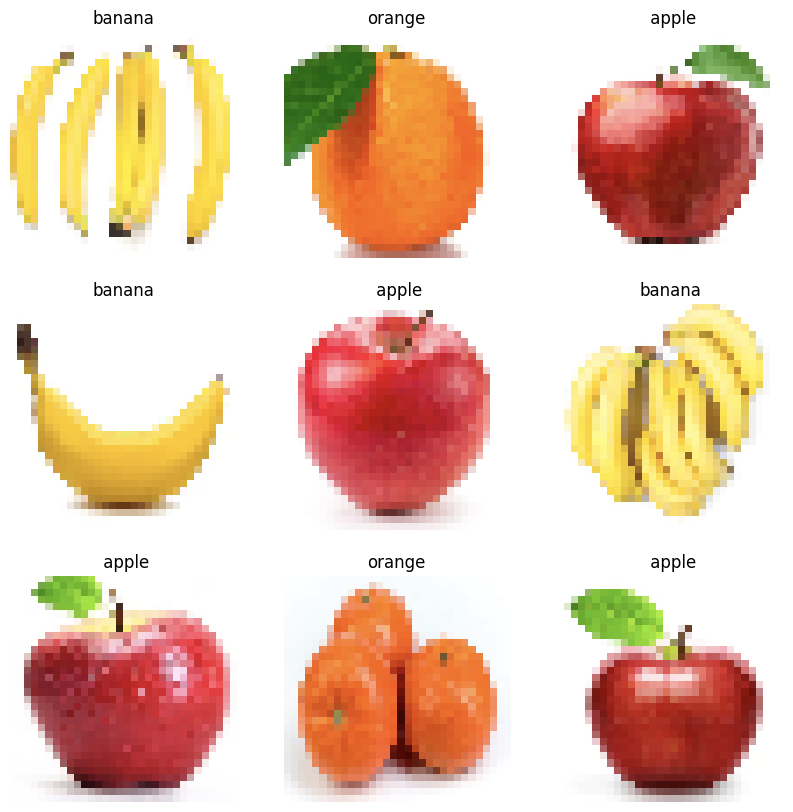

In [28]:
class_names = [" apple","banana","orange"]
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3,3, i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [29]:
model = tf.keras.Sequential(
    [
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="softmax"),# Malticlass hai isliye softmax use kare
    tf.keras.layers.Dense(3),                        # binary class me sigmoid use kr te(happy or sad wale me)
    ]
)

In [30]:
model.compile(
    optimizer = "rmsprop",
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics = ["accuracy"]
)

In [38]:
model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 20
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.9589 - loss: 0.5144 - val_accuracy: 0.9394 - val_loss: 0.5162
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.9777 - loss: 0.4813 - val_accuracy: 0.7121 - val_loss: 0.7452
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - accuracy: 0.9458 - loss: 0.5046 - val_accuracy: 0.9394 - val_loss: 0.4973
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.9580 - loss: 0.4795 - val_accuracy: 0.9545 - val_loss: 0.4834
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.9813 - loss: 0.4346 - val_accuracy: 0.9848 - val_loss: 0.4111
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.9740 - loss: 0.4317 - val_accuracy: 0.9545 - val_loss: 0.4549
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.9536 - loss: 0.4291 - val_accuracy: 0.9848 - val_loss: 0.4044
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.9758 - loss: 0.3949 - val_accuracy: 0.9394 - 

In [39]:
model.evaluate(test_ds)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9646 - loss: 0.2998


[0.3206919729709625, 0.9461538195610046]

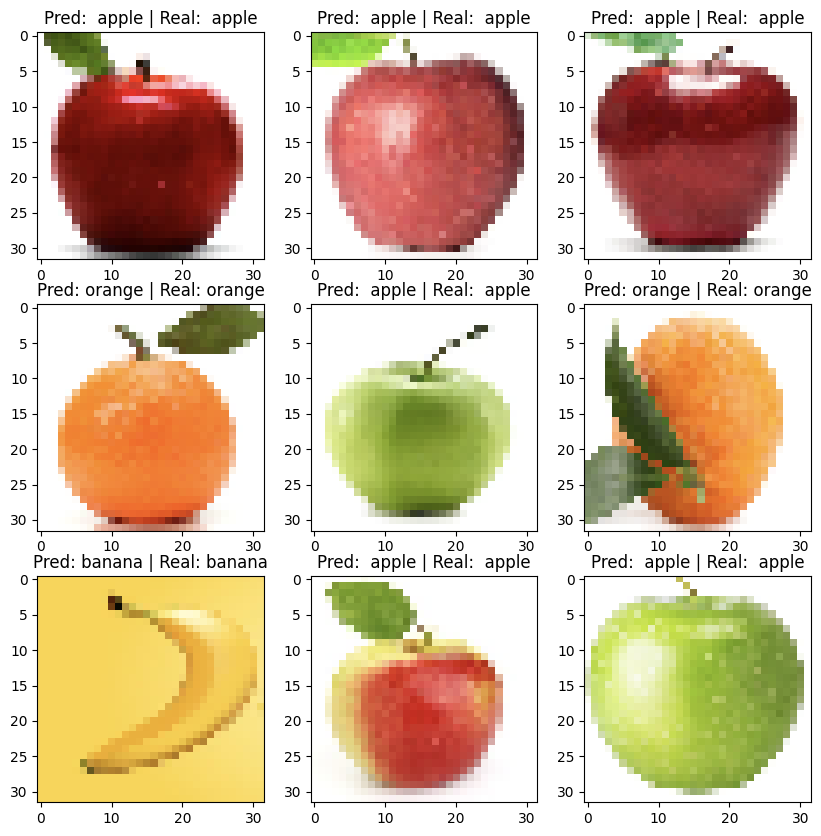

In [40]:
import numpy

plt.figure(figsize=(10, 10))
for images, labels in test_ds.take(1):
  classifications = model(images)
  #print(classifications)

  for i in range(9):
    ax = plt.subplot(3,3, i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    index = numpy.argmax(classifications[i])
    plt.title("Pred: " + class_names[index] + " | Real: " + class_names[labels[i]])


In [41]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# after model.tflite , i will share to android deveo

with open("model.tflite", 'wb') as f:
  f.write(tflite_model)

Saved artifact at '/tmp/tmp72nc43bh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor_11')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  132495683323664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132492499995344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132492499997072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132492499994192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132492499995536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132492499994960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132492499995152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132492499997264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132492499995920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132492499998416: TensorSpec(shape=(), dtype=tf.resource, name=None)
